In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('german_credit_data.csv', index_col=0)

# Rename German columns to English
df.columns = [
    'duration', 'credit_history', 'purpose', 'amount',
    'savings', 'employment_duration', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'present_residence',
    'property', 'age', 'other_installment_plans', 'housing',
    'number_credits', 'job', 'people_liable', 'telephone',
    'foreign_worker', 'credit_risk'
]

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTarget distribution:")
print(df['credit_risk'].value_counts())
print(f"\nFirst 5 rows:")
df.head()

Shape: (1000, 20)

Columns: ['duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

Target distribution:
credit_risk
1    700
0    300
Name: count, dtype: int64

First 5 rows:


,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
laufkont,,,,,,,,,,,,,,,,,,,,
1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


C:\Users\USER\AppData\Local\Temp\ipykernel_9204\1108792482.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_risk', y='amount', data=df,
C:\Users\USER\AppData\Local\Temp\ipykernel_9204\1108792482.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,2].set_xticklabels(['Bad', 'Good'])
C:\Users\USER\AppData\Local\Temp\ipykernel_9204\1108792482.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_risk', y='duration', data=df,
C:\Users\USER\AppData\Local\Temp\ipykernel_9204\1108792482.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

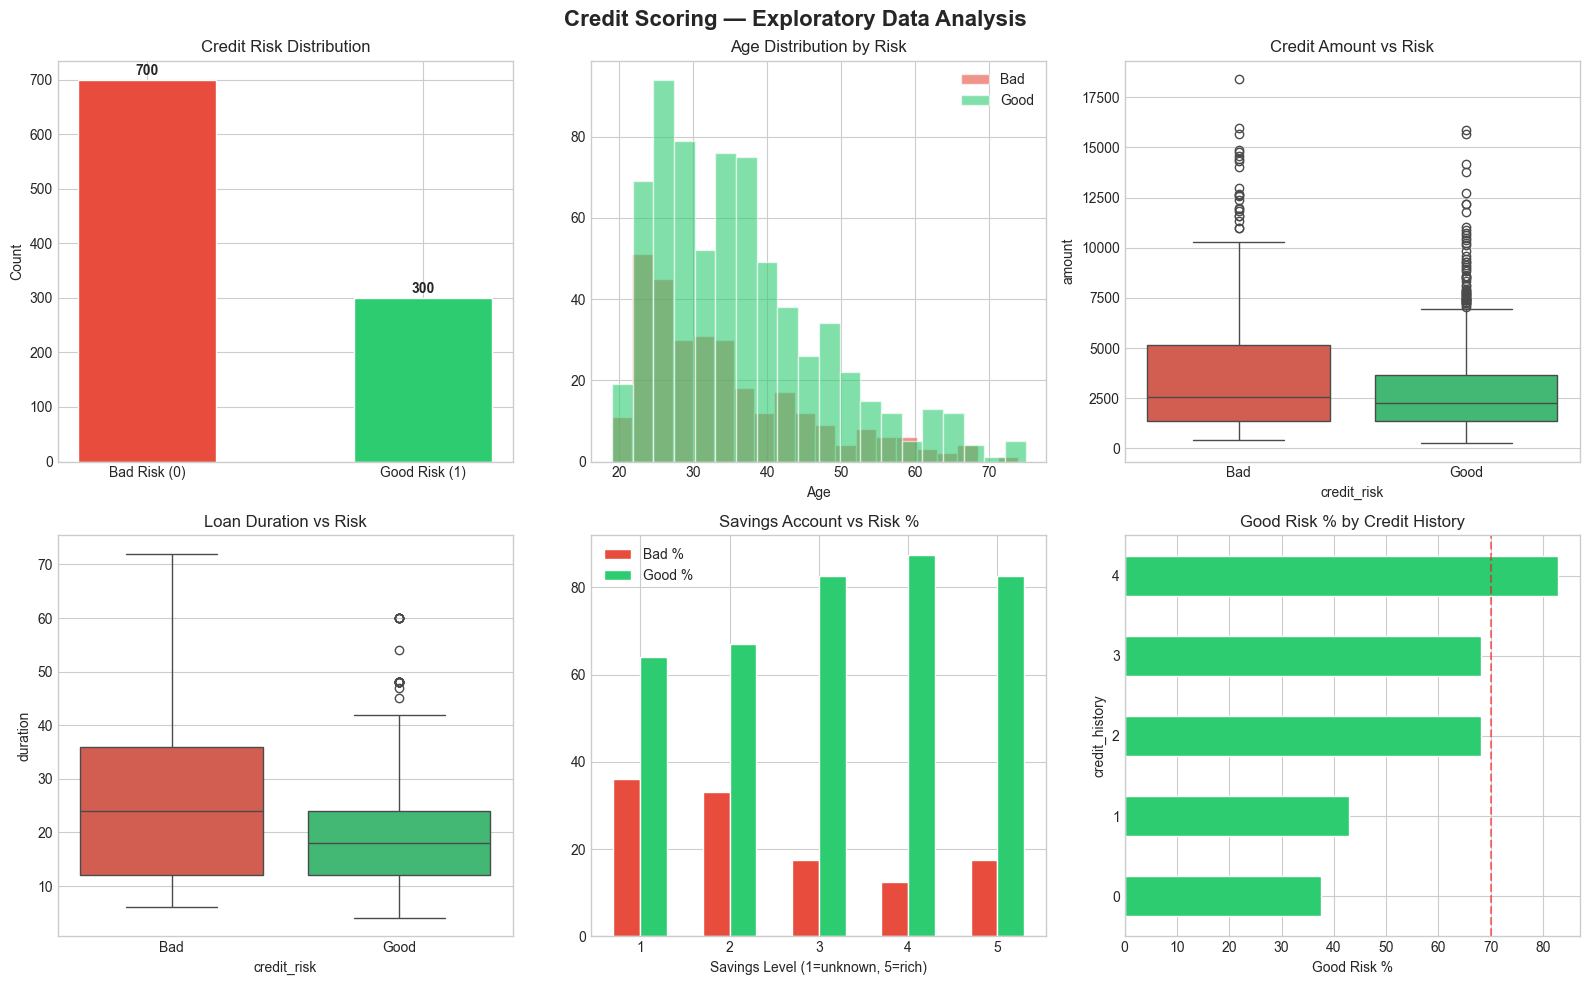


Key Stats:
  Avg Amount  — Good: 2985  Bad: 3938
  Avg Duration— Good: 19.2m  Bad: 24.9m
  Avg Age     — Good: 36.2  Bad: 34.0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix duplicate index
df = df.reset_index(drop=True)

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Scoring — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Target distribution
axes[0,0].bar(['Bad Risk (0)', 'Good Risk (1)'],
               df['credit_risk'].value_counts().values,
               color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0,0].set_title('Credit Risk Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df['credit_risk'].value_counts().values):
    axes[0,0].text(i, v + 8, str(v), ha='center', fontweight='bold')

# 2. Age vs Risk
for val, color, label in zip([0,1], ['#e74c3c','#2ecc71'], ['Bad','Good']):
    df[df['credit_risk']==val]['age'].hist(
        bins=20, alpha=0.6, color=color, label=label,
        ax=axes[0,1], edgecolor='white')
axes[0,1].set_title('Age Distribution by Risk')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# 3. Credit Amount vs Risk
sns.boxplot(x='credit_risk', y='amount', data=df,
            palette=['#e74c3c','#2ecc71'], ax=axes[0,2])
axes[0,2].set_title('Credit Amount vs Risk')
axes[0,2].set_xticklabels(['Bad', 'Good'])

# 4. Duration vs Risk
sns.boxplot(x='credit_risk', y='duration', data=df,
            palette=['#e74c3c','#2ecc71'], ax=axes[1,0])
axes[1,0].set_title('Loan Duration vs Risk')
axes[1,0].set_xticklabels(['Bad', 'Good'])

# 5. Savings vs Risk
ct = pd.crosstab(df['savings'], df['credit_risk'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[1,1], color=['#e74c3c','#2ecc71'],
        edgecolor='white', width=0.6)
axes[1,1].set_title('Savings Account vs Risk %')
axes[1,1].set_xlabel('Savings Level (1=unknown, 5=rich)')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].legend(['Bad %', 'Good %'])

# 6. Credit History vs Risk
ct2 = pd.crosstab(df['credit_history'], df['credit_risk'], normalize='index') * 100
ct2[1].sort_values().plot(kind='barh', ax=axes[1,2],
                           color='#2ecc71', edgecolor='white')
axes[1,2].set_title('Good Risk % by Credit History')
axes[1,2].set_xlabel('Good Risk %')
axes[1,2].axvline(70, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nKey Stats:")
print(f"  Avg Amount  — Good: {df[df.credit_risk==1]['amount'].mean():.0f}  Bad: {df[df.credit_risk==0]['amount'].mean():.0f}")
print(f"  Avg Duration— Good: {df[df.credit_risk==1]['duration'].mean():.1f}m  Bad: {df[df.credit_risk==0]['duration'].mean():.1f}m")
print(f"  Avg Age     — Good: {df[df.credit_risk==1]['age'].mean():.1f}  Bad: {df[df.credit_risk==0]['age'].mean():.1f}")

In [3]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── 1. Feature Engineering ───────────────────────────────────
# Repayment burden per month
df['amount_per_month'] = df['amount'] / df['duration']

# Age group buckets
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 25, 35, 50, 100],
                          labels=[0, 1, 2, 3]).astype(int)

# ── 2. Define features and target ───────────────────────────
X = df.drop(columns=['credit_risk'])
y = df['credit_risk']

print(f"Features ({X.shape[1]}): {X.columns.tolist()}")

# ── 3. Scale features ────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ── 4. Train/Test split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nClass balance in train:")
print(y_train.value_counts())

Features (21): ['duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'amount_per_month', 'age_group']

Training samples : 800
Testing samples  : 200

Class balance in train:
credit_risk
1    560
0    240
Name: count, dtype: int64


In [5]:
import sys
!{sys.executable} -m pip install scikit-learn

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── Define models ────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight='balanced')
}

# ── Stratified K-Fold ────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Cross-validation ─────────────────────────────────────────
print("=" * 50)
print(f"{'Model':<25} {'CV ROC-AUC':>12}  {'Std':>6}")
print("=" * 50)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                              cv=skf, scoring='roc_auc')
    print(f"{name:<25} {scores.mean():.4f}        ±{scores.std():.4f}")

print("=" * 50)

Model                       CV ROC-AUC     Std
Logistic Regression       0.7257        ±0.0507
Decision Tree             0.6403        ±0.0469
Random Forest             0.7312        ±0.0466


In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, auc)

# ── Train & evaluate each model ──────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }

# ── Summary table ─────────────────────────────────────────────
summary = pd.DataFrame({
    name: {k: round(v, 4) for k, v in res.items()
           if k not in ['model', 'y_pred', 'y_proba']}
    for name, res in results.items()
}).T

print("=" * 65)
print("         Model Evaluation on Test Set")
print("=" * 65)
print(summary.to_string())
print("=" * 65)

         Model Evaluation on Test Set
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.665     0.8476  0.6357    0.7265   0.7606
Decision Tree           0.670     0.7891  0.7214    0.7537   0.6414
Random Forest           0.765     0.8496  0.8071    0.8278   0.7801


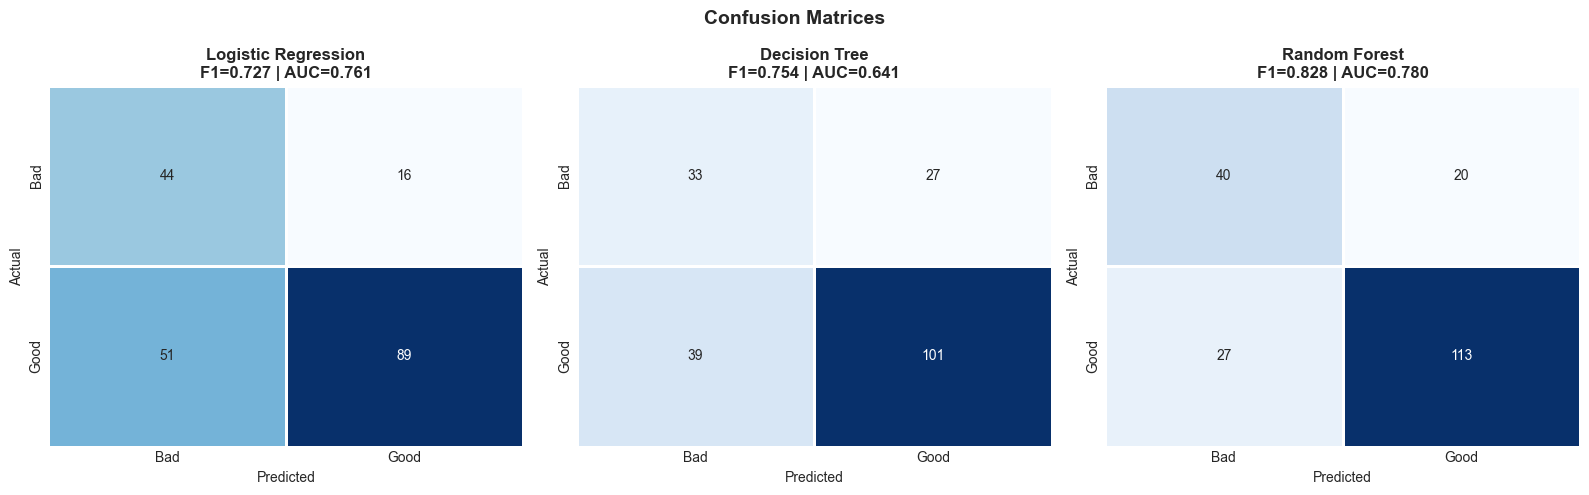

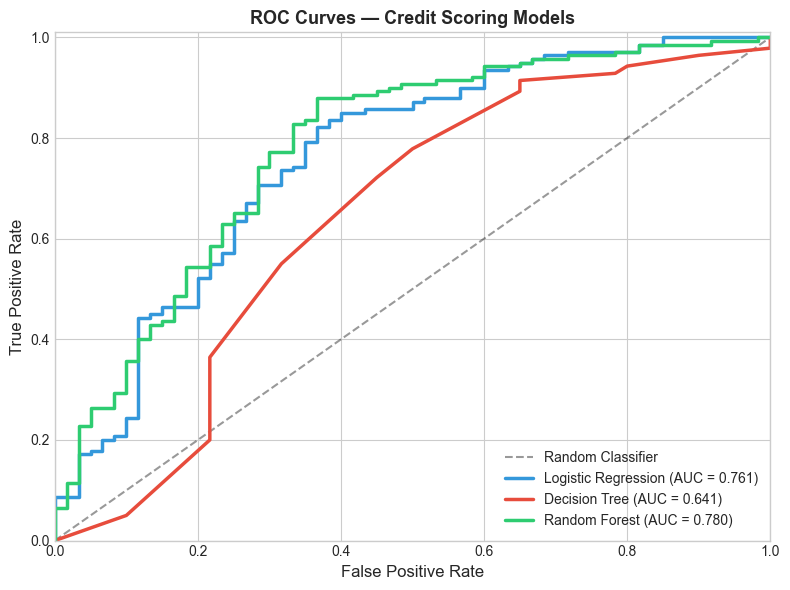

In [8]:
# ── Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bad', 'Good'],
                yticklabels=['Bad', 'Good'],
                linewidths=1, cbar=False)
    ax.set_title(f"{name}\nF1={res['F1-Score']:.3f} | AUC={res['ROC-AUC']:.3f}",
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ── ROC Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random Classifier')

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Credit Scoring Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

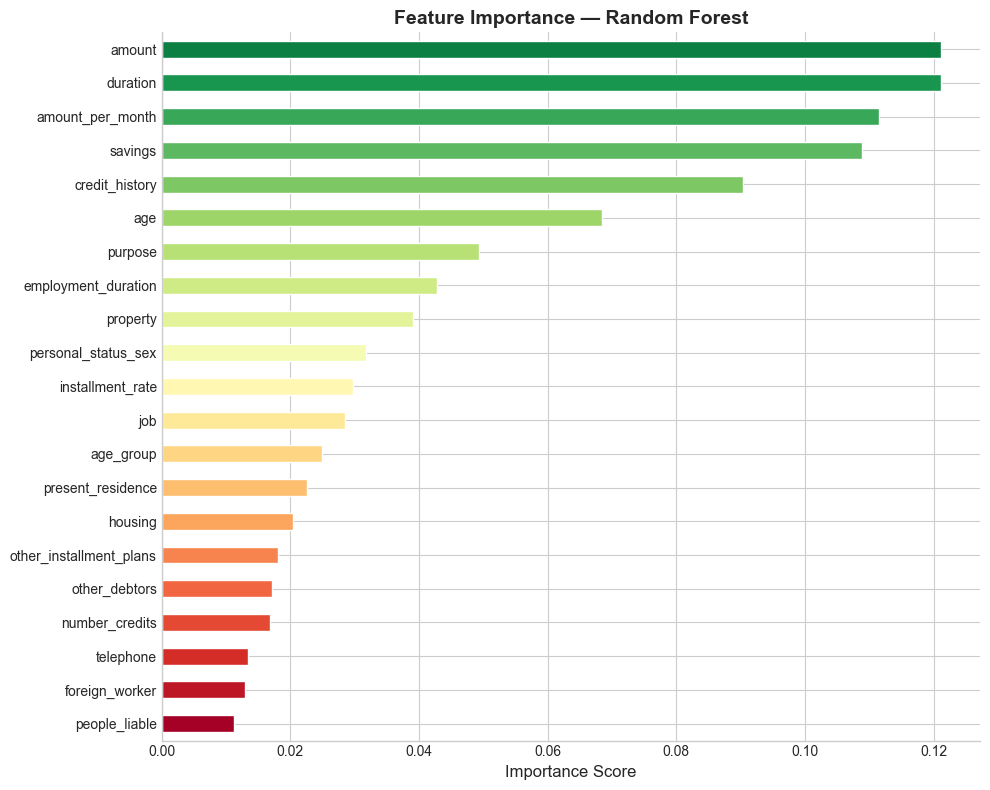

Top 5 most important features:
amount              0.1211
duration            0.1211
amount_per_month    0.1115
savings             0.1088
credit_history      0.0904


In [9]:
# ── Feature Importance (Random Forest) ───────────────────────
rf_model = results['Random Forest']['model']

feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.RdYlGn(
    [i/len(feat_importance) for i in range(len(feat_importance))]
)

feat_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Feature Importance — Random Forest', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_importance.sort_values(ascending=False).head(5).round(4).to_string())

In [10]:
print("=" * 60)
print("     CREDIT SCORING MODEL — FINAL SUMMARY")
print("=" * 60)

print("\n📊 Model Performance:")
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'AUC':>8}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<25} {res['Accuracy']:>9.4f} {res['Precision']:>10.4f} "
          f"{res['Recall']:>8.4f} {res['F1-Score']:>7.4f} {res['ROC-AUC']:>8.4f}")

print("\n🏆 Best Model: Random Forest")
print("   → Accuracy : 76.5%")
print("   → F1-Score : 0.828")
print("   → ROC-AUC  : 0.780")

print("\n🔑 Top 5 Predictive Features:")
top5 = feat_importance.sort_values(ascending=False).head(5)
for i, (feat, score) in enumerate(top5.items(), 1):
    print(f"   {i}. {feat:<25} ({score:.4f})")

print("\n💡 Key Insights:")
print("   • Bad risk borrowers request 32% more credit (3938 vs 2985)")
print("   • Bad risk loans last 5.7 months longer (24.9 vs 19.2)")
print("   • Higher savings = lower default risk (real financial signal)")
print("   • amount_per_month is the 3rd most important feature")
print("   • people_liable has the least predictive power")

print("\n📌 Why results are realistic (70-78% AUC):")
print("   • Using REAL historical data, not a synthetic formula")
print("   • Human financial behavior is complex and noisy")
print("   • 75-80% AUC is considered strong in real credit scoring")

print("\n✅ Task 1 Complete!")
print("=" * 60)

     CREDIT SCORING MODEL — FINAL SUMMARY

📊 Model Performance:
Model                      Accuracy  Precision   Recall      F1      AUC
------------------------------------------------------------
Logistic Regression          0.6650     0.8476   0.6357  0.7265   0.7606
Decision Tree                0.6700     0.7891   0.7214  0.7537   0.6414
Random Forest                0.7650     0.8496   0.8071  0.8278   0.7801

🏆 Best Model: Random Forest
   → Accuracy : 76.5%
   → F1-Score : 0.828
   → ROC-AUC  : 0.780

🔑 Top 5 Predictive Features:
   1. amount                    (0.1211)
   2. duration                  (0.1211)
   3. amount_per_month          (0.1115)
   4. savings                   (0.1088)
   5. credit_history            (0.0904)

💡 Key Insights:
   • Bad risk borrowers request 32% more credit (3938 vs 2985)
   • Bad risk loans last 5.7 months longer (24.9 vs 19.2)
   • Higher savings = lower default risk (real financial signal)
   • amount_per_month is the 3rd most important fe